In [146]:
import torch 
import torch.nn as nn                     
import torch.optim as optim               
import matplotlib.pyplot as plt
import numpy as np
torch.set_default_dtype(torch.float)
torch.manual_seed(1234)
np.random.seed(1234)
from sklearn.model_selection import train_test_split

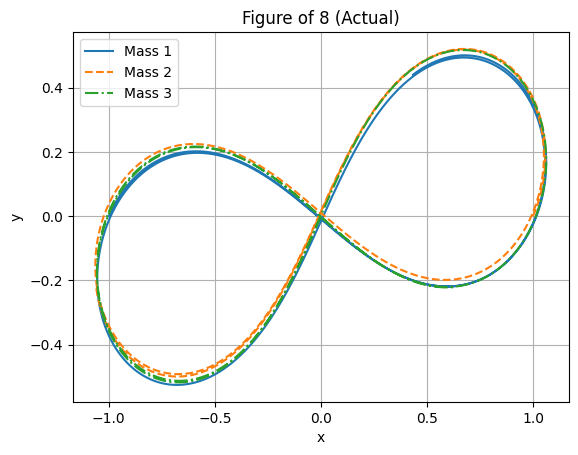

In [167]:
G=1
dt=0.01
t=np.arange(0,10+dt,dt)
nt=len(t)
m1,m2,m3=1,1,1
r1,r2,r3=np.zeros((nt,2)),np.zeros((nt,2)),np.zeros((nt,2))
v1,v2,v3=np.zeros((nt,2)),np.zeros((nt,2)),np.zeros((nt,2))
def f1(r,m2,m3,j):
    return -G*(m2*(r[0][j]-r[1][j])/(np.linalg.norm((r[0][j]-r[1][j])))**3+m3*(r[0][j]-r[2][j])/(np.linalg.norm((r[0][j]-r[2][j]))**3))
def f2(r,m1,m3,j):
    return -G*(m1*(r[1][j]-r[0][j])/(np.linalg.norm((r[1][j]-r[0][j])))**3+m3*(r[1][j]-r[2][j])/(np.linalg.norm((r[1][j]-r[2][j]))**3))
def f3(r,m1,m2,j):
    return -G*(m1*(r[2][j]-r[0][j])/(np.linalg.norm((r[2][j]-r[0][j])))**3+m2*(r[2][j]-r[1][j])/(np.linalg.norm((r[2][j]-r[1][j]))**3))
def lfrog(r,v):
    for i in range(len(t)-1):
        r[0][i+1]=r[0][i]+v[0][i]*dt+f1(r,m2,m3,i)*0.5*dt**2
        r[1][i+1]=r[1][i]+v[1][i]*dt+f2(r,m1,m3,i)*0.5*dt**2
        r[2][i+1]=r[2][i]+v[2][i]*dt+f3(r,m1,m2,i)*0.5*dt**2
        v[0][i+1]=v[0][i]+0.5*dt*(f1(r,m2,m3,i)+f1(r,m2,m3,i+1))
        v[1][i+1]=v[1][i]+0.5*dt*(f2(r,m1,m3,i)+f2(r,m1,m3,i+1))
        v[2][i+1]=v[2][i]+0.5*dt*(f3(r,m1,m2,i)+f3(r,m1,m2,i+1))
    return r,v 
# For 8 path:
r1[0]=[-1.00,0.00]
v1[0]=[0.3489,0.5306]
r2[0]=-r1[0]
v2[0]=v1[0]
v3[0]=-2*v1[0]
r=[r1,r2,r3];v=[v1,v2,v3]
r_new,v_new=lfrog(r,v)
plt.plot(r_new[0][:,0],r_new[0][:,1],label='Mass 1')
plt.plot(r_new[1][:,0],r_new[1][:,1],linestyle='--',label="Mass 2")
plt.plot(r_new[2][:,0],r_new[2][:,1],linestyle='-.',label='Mass 3')
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Figure of 8 (Actual)")
plt.show()

In [153]:
x1=r_new[0][:,0][:,None];y1=r_new[0][:,1][:,None]
x2=r_new[1][:,0][:,None];y2=r_new[1][:,1][:,None]
x3=r_new[2][:,0][:,None];y3=r_new[2][:,1][:,None]

In [154]:
X_u_test=t[:,None]
u_true=np.concatenate((x1,x2,x3),axis=1)
lb=np.array([0.0])
ub=np.array([10.0])

In [155]:
N_f = 1001 #Total number of collocation points 
X_f_train_np_array = np.linspace(0,10,N_f)[:,None] # collocation points
X_f_train=torch.from_numpy(X_f_train_np_array).float()
X_u_test_tensor = torch.from_numpy(X_u_test).float()
u_true_tensor = torch.from_numpy(u_true).float()

In [168]:
class OrbitPINN(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.iter = 0
        self.activation= nn.Tanh()
        self.loss_func=nn.MSELoss(reduction='sum')
        self.fc1=nn.Linear(1,84)# Input->Hidden1
        self.fc2=nn.Linear(84,84)# Hidden1->Hidden2
        self.fc3=nn.Linear(84,84)# Hidden2->Hidden3
        self.fc4=nn.Linear(84,84)# Hidden2->Hidden3
        self.fc5=nn.Linear(84,84)# Hidden2->Hidden3
        self.fc6=nn.Linear(84,3)# Hidden3->Output
        
    #FORWARD PASSING
    
    # def sin_act(self,x):
    #     return torch.sin(x)

    def forward(self,x):
        u_b=torch.from_numpy(ub).float()
        l_b=torch.from_numpy(lb).float()
        x=(x-l_b)/(u_b-l_b) # Feature Scaling
        a=x.float()
        a=self.activation(self.fc1(a))
        a=self.activation(self.fc2(a))
        a=self.activation(self.fc3(a))
        a= self.activation(self.fc4(a))
        a= self.activation(self.fc5(a))
        a= self.fc6(a)
        return a
    
    def data_loss(self, x_to_train_f,u_true_tensor):
        g = x_to_train_f.clone()          
        g.requires_grad = True
        u = self.forward(g)
        loss_data = self.loss_func(u,u_true_tensor)
        return loss_data
    
    def test(self,X_u_test_tensor,u_true_tensor):        
        u_pred = self.forward(X_u_test_tensor)
        error_vec = torch.linalg.norm((u_true_tensor-
                                       u_pred),2)/torch.linalg.norm(u_true_tensor,2)   
        u_pred=u_pred.detach().numpy()      
        return error_vec, u_pred 

In [169]:
orbit = OrbitPINN()

'Neural Network Summary'
print(orbit)

params = list(orbit.parameters())
'''Optimization'''
step_size= 1
gamma= 0.99
optimizer = torch.optim.Adam(orbit.parameters(),lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
max_iter= 4000

OrbitPINN(
  (activation): Tanh()
  (loss_func): MSELoss()
  (fc1): Linear(in_features=1, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=84, bias=True)
  (fc4): Linear(in_features=84, out_features=84, bias=True)
  (fc5): Linear(in_features=84, out_features=84, bias=True)
  (fc6): Linear(in_features=84, out_features=3, bias=True)
)


In [170]:
for i in range(max_iter):
    loss=orbit.data_loss(X_f_train,u_true_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # scheduler.step()
    if i%400==0:
        print(f"Total Loss:{loss.item()}")

Total Loss:1723.631103515625
Total Loss:3.2439627647399902
Total Loss:0.4139838218688965
Total Loss:3.346454620361328
Total Loss:6.337617874145508
Total Loss:3.173041582107544
Total Loss:2.978175401687622
Total Loss:0.16957730054855347
Total Loss:0.8859843611717224
Total Loss:1.373753309249878


In [171]:
error_vec,u_pred=orbit.test(X_u_test_tensor,u_true_tensor)
print(f"Relative Error:{error_vec}")

Relative Error:0.036534037441015244


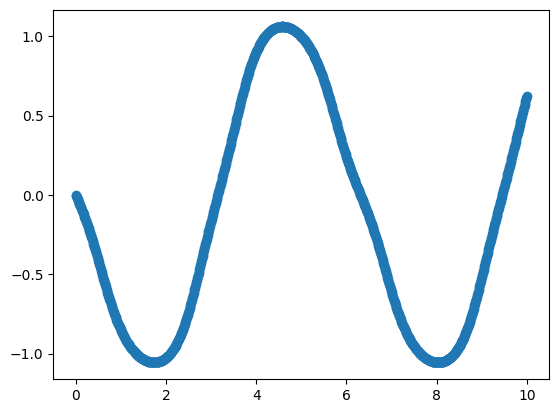

In [160]:
plt.scatter(t,x3)

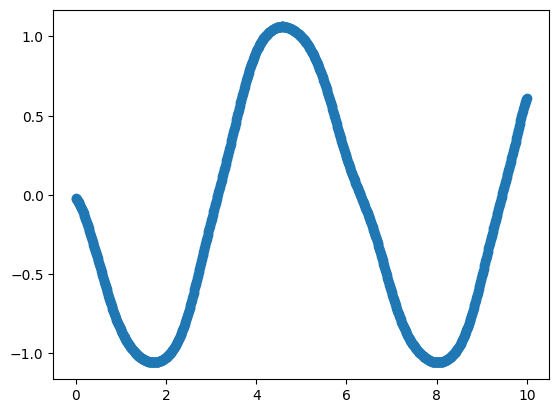

In [161]:
plt.scatter(t,u_pred[:,2])

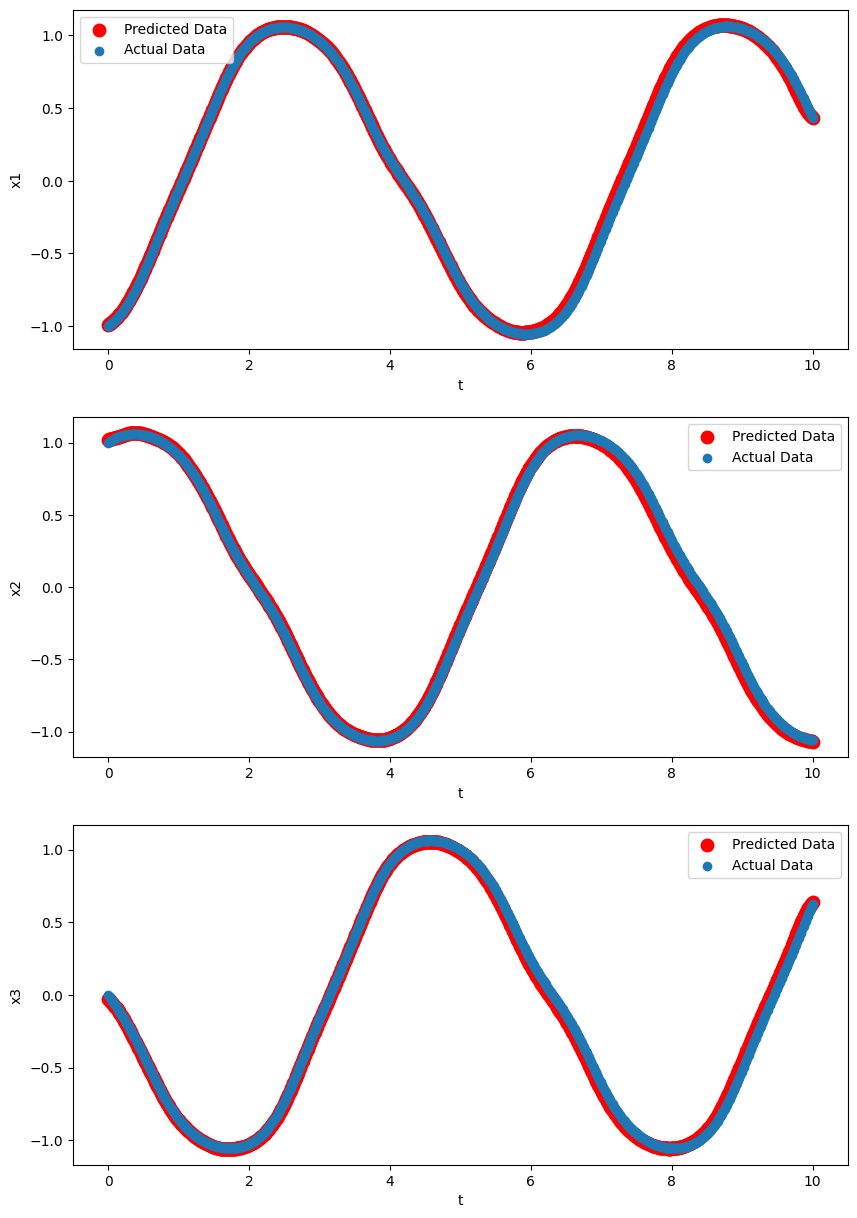

In [172]:
plt.figure(figsize=(10,15))
plt.subplot(3,1,1)
plt.scatter(t,u_pred[:,0],color = 'r',linewidth =4,label="Predicted Data")
plt.scatter(t,x1,label='Actual Data')
plt.xlabel('t')
plt.ylabel('x1')
plt.legend()
plt.subplot(3,1,2)
plt.scatter(t,u_pred[:,1],color = 'r',linewidth =4,label="Predicted Data")
plt.scatter(t,x2,label='Actual Data')
plt.xlabel('t')
plt.ylabel('x2')
plt.legend()
plt.subplot(3,1,3)
plt.scatter(t,u_pred[:,2],color = 'r',linewidth =4,label="Predicted Data")
plt.scatter(t,x3,label='Actual Data')
plt.xlabel('t')
plt.ylabel('x3')
plt.legend()

Now, we repeat the training process for **Y-Data** as well

In [96]:
Y_u_test=t[:,None]
u_true_y=np.concatenate((y1,y2,y3),axis=1)
lb_y=np.array([0.0])
ub_y=np.array([10.0])

In [97]:
N_f = 1001 #Total number of collocation points 
Y_f_train_np_array = np.linspace(0,10,N_f)[:,None] # collocation points
Y_f_train=torch.from_numpy(Y_f_train_np_array).float()
Y_u_test_tensor = torch.from_numpy(Y_u_test).float()
u_true_y_tensor = torch.from_numpy(u_true_y).float()

In [173]:
class OrbitPINN_Y(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.iter = 0
        self.activation= nn.Tanh()
        self.loss_func=nn.MSELoss(reduction='sum')
        self.fc1=nn.Linear(1,84)# Input->Hidden1
        self.fc2=nn.Linear(84,84)# Hidden1->Hidden2
        self.fc3=nn.Linear(84,84)# Hidden2->Hidden3
        self.fc4=nn.Linear(84,84)# Hidden2->Hidden3
        self.fc5=nn.Linear(84,84)# Hidden2->Hidden3
        self.fc6=nn.Linear(84,3)# Hidden3->Output
        
    #FORWARD PASSING
    
    # def sin_act(self,x):
    #     return torch.sin(x)

    def forward(self,x):
        u_b_y=torch.from_numpy(ub_y).float()
        l_b_y=torch.from_numpy(lb_y).float()
        x=(x-l_b_y)/(u_b_y-l_b_y) # Feature Scaling
        a=x.float()
        a=self.activation(self.fc1(a))
        a=self.activation(self.fc2(a))
        a=self.activation(self.fc3(a))
        a= self.activation(self.fc4(a))
        a= self.activation(self.fc5(a))
        a= self.fc6(a)
        return a
    
    def data_loss(self, y_to_train_f,u_true_tensor):
        g = y_to_train_f.clone()          
        g.requires_grad = True
        u = self.forward(g)
        loss_data = self.loss_func(u,u_true_tensor)
        return loss_data
    
    def test(self,Y_u_test_tensor,u_true_tensor):        
        u_pred = self.forward(Y_u_test_tensor)
        error_vec = torch.linalg.norm((u_true_tensor-u_pred),2)/torch.linalg.norm(u_true_tensor,2)   
        u_pred=u_pred.detach().numpy()    
        return error_vec, u_pred 

In [174]:
orbit_y = OrbitPINN_Y()

'Neural Network Summary'
print(orbit_y)

params = list(orbit_y.parameters())
'''Optimization'''
step_size= 1
gamma= 0.99
optimizer = torch.optim.Adam(orbit_y.parameters(),lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
max_iter= 4000

OrbitPINN_Y(
  (activation): Tanh()
  (loss_func): MSELoss()
  (fc1): Linear(in_features=1, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=84, bias=True)
  (fc4): Linear(in_features=84, out_features=84, bias=True)
  (fc5): Linear(in_features=84, out_features=84, bias=True)
  (fc6): Linear(in_features=84, out_features=3, bias=True)
)


In [175]:
for i in range(max_iter):
    loss=orbit_y.data_loss(Y_f_train,u_true_y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # scheduler.step()
    if i%400==0:
        print(f"Total Loss:{loss.item()}")

Total Loss:276.73175048828125
Total Loss:3.044173240661621
Total Loss:0.13819074630737305
Total Loss:0.7783766388893127
Total Loss:0.2225593626499176
Total Loss:0.49507319927215576
Total Loss:0.18865250051021576
Total Loss:0.4110027551651001
Total Loss:0.1599155068397522
Total Loss:0.30512484908103943


In [176]:
error_vec_y,u_pred_y=orbit_y.test(Y_u_test_tensor,u_true_y_tensor)
print(f"Relative Error:{error_vec_y}")

Relative Error:0.027753835543990135


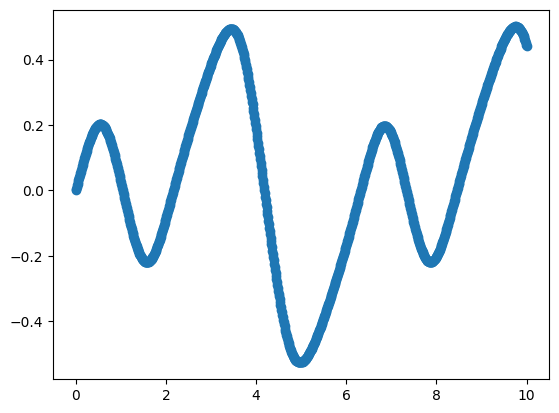

In [103]:
plt.scatter(t,y1)

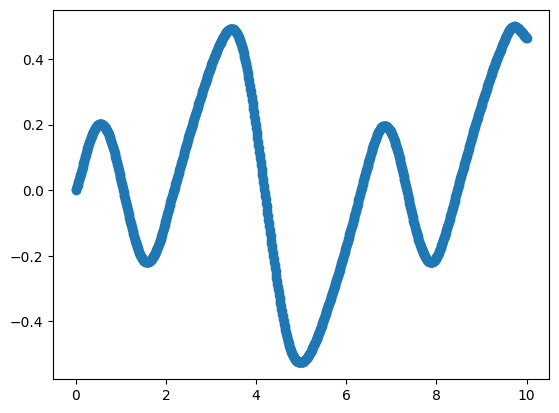

In [104]:
plt.scatter(t,u_pred_y[:,0])

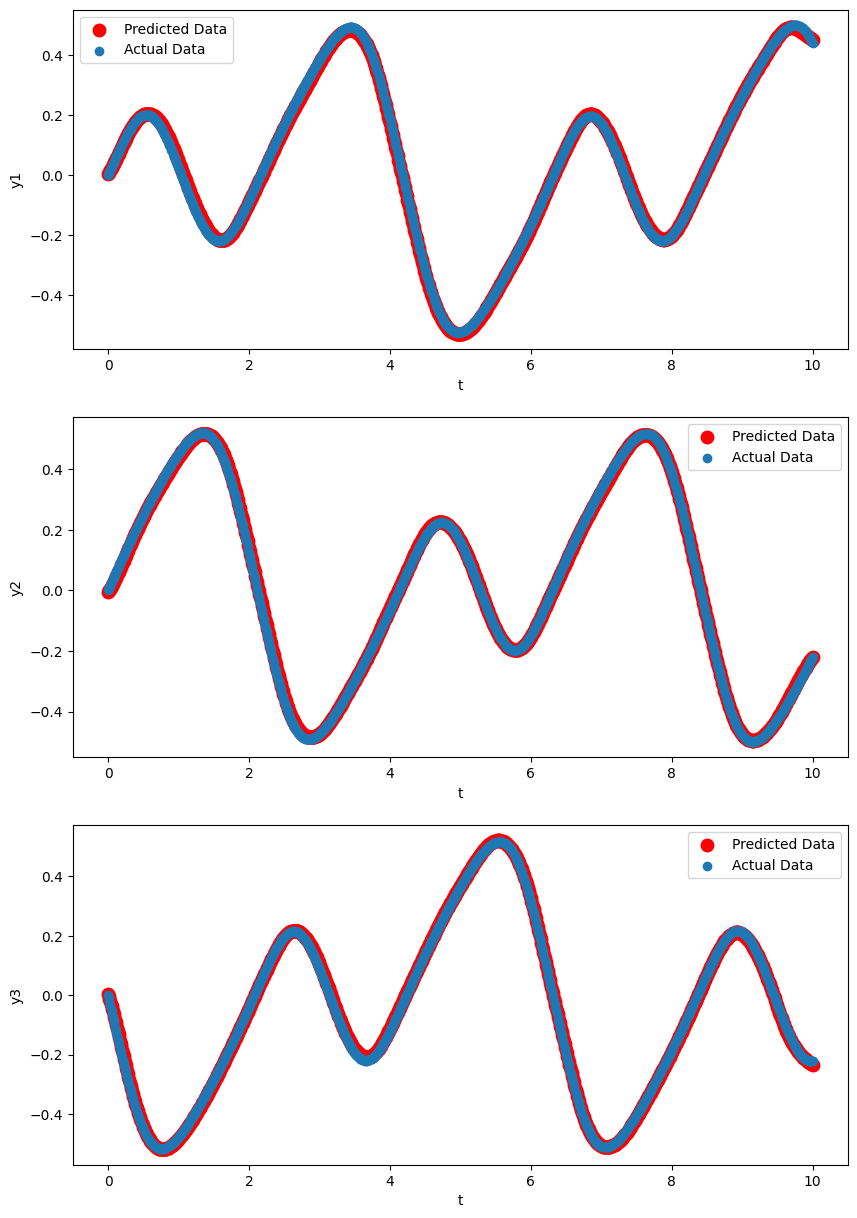

In [177]:
plt.figure(figsize=(10,15))
plt.subplot(3,1,1)
plt.scatter(t,u_pred_y[:,0],color = 'r',linewidth =4,label="Predicted Data")
plt.scatter(t,y1,label='Actual Data')
plt.xlabel('t')
plt.ylabel('y1')
plt.legend()
plt.subplot(3,1,2)
plt.scatter(t,u_pred_y[:,1],color = 'r',linewidth =4,label="Predicted Data")
plt.scatter(t,y2,label='Actual Data')
plt.xlabel('t')
plt.ylabel('y2')
plt.legend()
plt.subplot(3,1,3)
plt.scatter(t,u_pred_y[:,2],color = 'r',linewidth =4,label="Predicted Data")
plt.scatter(t,y3,label='Actual Data')
plt.xlabel('t')
plt.ylabel('y3')
plt.legend()

Text(0.5, 1.0, 'Figure of 8 (Predicted)')

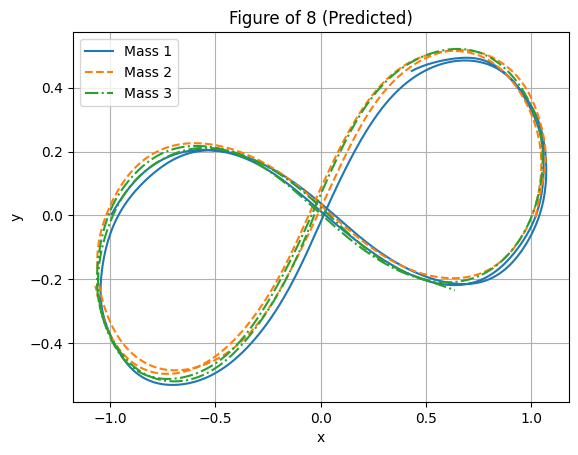

In [178]:
x1_pred=u_pred[:,0][:,None];y1_pred=u_pred_y[:,0][:,None]
x2_pred=u_pred[:,1][:,None];y2_pred=u_pred_y[:,1][:,None]
x3_pred=u_pred[:,2][:,None];y3_pred=u_pred_y[:,2][:,None]
r1_pred=np.concatenate((x1_pred,y1_pred),axis=1)
r2_pred=np.concatenate((x2_pred,y2_pred),axis=1)
r3_pred=np.concatenate((x3_pred,y3_pred),axis=1)
plt.plot(r1_pred[:,0],r1_pred[:,1],label='Mass 1')
plt.plot(r2_pred[:,0],r2_pred[:,1],linestyle='--',label="Mass 2")
plt.plot(r3_pred[:,0],r3_pred[:,1],linestyle='-.',label='Mass 3')
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Figure of 8 (Predicted)")